In [1]:
# 自动重新加载模块，以便在修改 d2l_utils.py 后无需重启内核即可生效
%load_ext autoreload
%autoreload 2
# 设置 matplotlib 在 notebook 中内联显示图像
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import sys
import os
import importlib

# 添加项目根目录到 sys.path，以便导入 d2l_utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import d2l_utils
importlib.reload(d2l_utils) # 强制重新加载模块，确保使用最新的代码

# 设置批量大小和时间步数
batch_size, num_steps = 32, 35
# 使用本地 d2l_utils 中的 load_data_time_machine 加载时光机器数据集
# train_iter 是数据迭代器，vocab 是词表
train_iter, vocab = d2l_utils.load_data_time_machine(batch_size, num_steps)


In [2]:
# One-hot encoding check
# 检查 one-hot 编码功能，将索引 [0, 2] 转换为 one-hot 向量
F.one_hot(torch.tensor([0, 3,5]), len(vocab))


tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

In [3]:
# Initializing Model Parameters
def get_params(vocab_size, num_hiddens, device):
    """初始化模型参数"""
    # 输入和输出的维度都等于词表大小
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        # 生成均值为0，方差为0.01的正态分布随机数
        return torch.randn(size=shape, device=device) * 0.01

    # 隐藏层参数
    # W_xh: 输入到隐藏层的权重
    W_xh = normal((num_inputs, num_hiddens))
    # W_hh: 隐藏层到隐藏层的权重
    W_hh = normal((num_hiddens, num_hiddens))
    # b_h: 隐藏层的偏置
    b_h = torch.zeros(num_hiddens, device=device)
    # 输出层参数
    # W_hq: 隐藏层到输出层的权重
    W_hq = normal((num_hiddens, num_outputs))
    # b_q: 输出层的偏置
    b_q = torch.zeros(num_outputs, device=device)
    # 将所有参数放入列表，并设置 requires_grad=True 以便计算梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params


In [4]:
# RNN Model
def init_rnn_state(batch_size, num_hiddens, device):
    """初始化 RNN 的隐藏状态"""
    # 返回一个元组，包含一个全零的张量，形状为 (batch_size, num_hiddens)
    return (torch.zeros((batch_size, num_hiddens), device=device), )

def rnn(inputs, state, params):
    """RNN 的前向传播逻辑"""
    # inputs shape: (num_steps, batch_size, vocab_size)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # 遍历每个时间步的输入
    for X in inputs:
        # 计算当前时间步的隐藏状态 H
        # H = tanh(X * W_xh + H_prev * W_hh + b_h)
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        # 计算当前时间步的输出 Y
        # Y = H * W_hq + b_q
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    # 将所有时间步的输出拼接在一起，形状为 (num_steps * batch_size, vocab_size)
    return torch.cat(outputs, dim=0), (H,)

class RNNModelScratch:
    """从零开始实现的 RNN 模型类"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        # 初始化参数
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state = init_state
        self.forward_fn = forward_fn

    def __call__(self, X, state):
        # 将输入 X 转置并进行 one-hot 编码，转换为浮点数
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        # 调用前向传播函数
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        # 初始化隐藏状态
        return self.init_state(batch_size, self.num_hiddens, device)


In [5]:
# Prediction
def predict_ch8(prefix, num_preds, net, vocab, device):
    """在 `prefix` 后面生成新字符"""
    # 初始化隐藏状态，batch_size 为 1
    state = net.begin_state(batch_size=1, device=device)
    # 将 prefix 的第一个字符转换为索引
    outputs = [vocab[prefix[0]]]
    # 定义一个 lambda 函数，用于获取最新的输入（上一个预测的字符）
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    # 预热期：使用 prefix 中的字符更新隐藏状态，但不记录输出
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    # 预测期：生成 num_preds 个新字符
    for _ in range(num_preds):
        # 使用上一个字符和当前状态进行预测
        y, state = net(get_input(), state)
        # 将预测结果（概率最大的索引）添加到 outputs
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    # 将索引转换回字符并拼接成字符串
    return ''.join([vocab.idx_to_token[i] for i in outputs])


In [6]:
# Gradient Clipping
def grad_clipping(net, theta):
    """梯度裁剪，防止梯度爆炸"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    # 计算所有参数梯度的 L2 范数
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    # 如果范数超过阈值 theta，则按比例缩小梯度
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm


In [7]:
# Training
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 累加器：训练损失之和，词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 如果是第一次迭代或使用随机抽样，初始化状态
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            # 否则，分离状态以切断计算图，防止梯度反向传播到之前的批次
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        # 将标签 Y 转置并展平
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        # 前向传播
        y_hat, state = net(X, state)
        # 计算损失
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            # 因为已经调用了 mean 函数，所以 batch_size 传 1
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    # 返回困惑度（perplexity）和每秒处理的词元数
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    # 动画绘制器，用于实时显示训练进度
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    # 定义预测函数，用于在训练过程中观察生成效果
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 训练循环
    ppl, speed = 0.0, 0.0
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        # 每 10 个 epoch 打印一次预测结果并更新图表
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'perplexity {ppl:.1f}, {speed:.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))


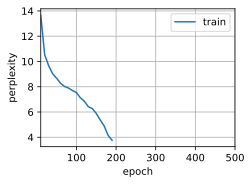

In [8]:
# Execution
num_hiddens = 512 # 隐藏单元数量
# 创建 RNN 模型实例
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
num_epochs, lr = 500, 1 # 迭代周期和学习率
# 开始训练
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())
